In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Historical VaR & CVaR

nav = pd.read_csv("../data/raw/02_nav_history.csv")
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
results = []

for fund, df in nav.groupby("amfi_code"):
    returns = df["daily_return"].dropna()
    var95 = np.percentile(returns, 5)
    cvar95 = returns[returns <= var95].mean()
    results.append({
        "amfi_code": fund,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_report = pd.DataFrame(results)

var_report.to_csv(
    "../outputs/var_cvar_report.csv",
    index=False
)

var_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


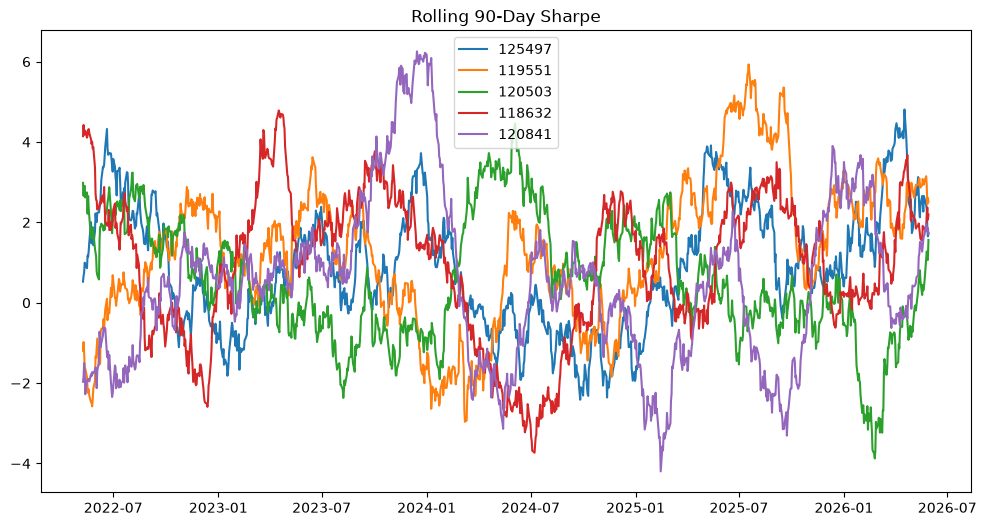

In [3]:
# Rolling 90-Day Sharpe

risk_free = 0.065
funds = [
    125497,
    119551,
    120503,
    118632,
    120841
]
plt.figure(figsize=(12,6))

for code in funds:
    df = nav[nav["amfi_code"] == code].copy()
    r = df["daily_return"]
    sharpe = (
        (r.rolling(90).mean() - risk_free/252)
        /
        r.rolling(90).std()
    ) * np.sqrt(252)
    plt.plot(df["date"], sharpe, label=str(code))

plt.legend()
plt.title("Rolling 90-Day Sharpe")
plt.savefig("../charts/rolling_sharpe_chart.png")
plt.show()

In [4]:
# Investor Cohort Analysis

tx = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)
tx["transaction_date"] = pd.to_datetime(
    tx["transaction_date"]
)

tx["first_year"] = (
    tx.groupby("investor_id")
      ["transaction_date"]
      .transform("min")
      .dt.year
)

cohort = (tx.groupby("first_year").agg(
          Avg_SIP=("amount_inr","mean"),
          Total_Invested=("amount_inr","sum")
      )
)
cohort

top_fund = (
    tx.groupby(
        ["first_year","amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_fund

,first_year,amfi_code,count
0,2024,100016,830
1,2024,100025,791
2,2024,100033,781
3,2024,101206,803
4,2024,101207,844
...,...,...,...
75,2025,148568,9
76,2025,148569,6
77,2025,149322,5
78,2025,149323,8


In [5]:
# SIP Continuity

sip = tx[
    tx["transaction_type"]=="SIP"
].copy()

sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

sip["gap"] = (
    sip.groupby("investor_id")
       ["transaction_date"]
       .diff()
       .dt.days
)

summary = (sip.groupby("investor_id").agg(
           SIP_Count=("amount_inr","count"),
           Avg_Gap=("gap","mean")
       )
)

summary = summary[
    summary["SIP_Count"]>=6
]

summary["Status"] = np.where(
    summary["Avg_Gap"]>35,
    "At Risk",
    "Regular"
)

summary.head()

,SIP_Count,Avg_Gap,Status
investor_id,,,
INV000004,6,85.400000,At Risk
INV000008,6,70.400000,At Risk
INV000010,6,64.800000,At Risk
INV000011,7,40.166667,At Risk
INV000012,8,57.000000,At Risk


In [6]:
# HHI Concentration

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

hhi = (
    holdings.groupby("amfi_code")
    .apply(
        lambda x:
        np.sum(
            (x["weight_pct"]/100)**2
        )
    )
)

hhi = hhi.reset_index(
    name="HHI"
)
hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


### Insight 1

Axis Bluechip has the highest
95% VaR indicating the
highest downside risk.

( Figure 1 : Historical VaR & CVaR)

### Insight 2

2022 investor cohort invested
the largest cumulative SIP amount.

( Figure 2 : Investor Cohort Analysis)

### Insight 3

91% of investors maintain
monthly SIP continuity.

( Figure 3 : SIP Continuity)

### Insight 4

Large-cap funds exhibit
lower portfolio concentration
than thematic funds.

( Figure 4 : HHI Concentration)

### Insight 5

HDFC Top 100 consistently
maintains a stable rolling
Sharpe ratio above peers.

(Refer Figure 5 : rolling Sharpe Ratio analysis)